In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

/Users/jesucastin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
rmsd_data=pd.read_csv('../../data/RMSD_RMSF/RMSD_dat.csv')
rmsd_data=rmsd_data[:1000]
rmsd_data

,proLC3B,ProLC3B_S1,ProLC3B_S2,ProLC3B_S3,Unnamed: 4,LC3B II,LC3BII_S1,LC3BII_S2,LC3BII_S3,Unnamed: 9,LC3BII_p62,LC3BII_p62_S1,LC3BII_p62_S2,LC3BII_p62_S3
0,0,0.000146,0.000146,0.000146,NaN,0.0,8.000000e-07,0.000137,0.000517,NaN,0.0,0.183775,0.183775,0.183776
1,1000,0.310701,0.262628,0.268099,NaN,1000.0,2.139222e-01,0.189021,0.184487,NaN,1000.0,0.157485,0.166495,0.152332
2,2000,0.284419,0.301087,0.312100,NaN,2000.0,2.210176e-01,0.188386,0.205279,NaN,2000.0,0.145390,0.160087,0.147309
3,3000,0.312285,0.355137,0.290206,NaN,3000.0,2.244698e-01,0.182112,0.206535,NaN,3000.0,0.198953,0.171657,0.192634
4,4000,0.313465,0.280035,0.309174,NaN,4000.0,2.170848e-01,0.170895,0.193378,NaN,4000.0,0.204886,0.191763,0.211684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995000,0.380167,0.434172,0.476167,NaN,995000.0,3.473829e-01,0.252788,0.370716,NaN,995000.0,0.214890,0.389084,0.245366
996,996000,0.382037,0.442125,0.477503,NaN,996000.0,3.619345e-01,0.257242,0.394635,NaN,996000.0,0.207263,0.387967,0.249189
997,997000,0.372633,0.443667,0.476007,NaN,997000.0,3.722055e-01,0.269058,0.430265,NaN,997000.0,0.198381,0.389731,0.255693
998,998000,0.367672,0.432917,0.470419,NaN,998000.0,3.777209e-01,0.259986,0.416091,NaN,998000.0,0.217347,0.399353,0.264380


In [3]:
time_splits=[i for i in range(0,1002,200)]
t_range=[]
for t_ind in range(len(time_splits)-1):
    print (time_splits[t_ind],time_splits[t_ind+1])
    t_range.append((time_splits[t_ind],time_splits[t_ind+1]))

0 200
200 400
400 600
600 800
800 1000


In [4]:
labels=['A 0ns-200ns', 'B 201ns-400ns', 'C 401ns-600ns', 'D 601ns-800ns', 'E 801ns-1000ns']
tr_lab=[]
for NO,t_r in enumerate(t_range):
    if NO==0:
        for i in range(t_r[0],t_r[1]+1):
            tr_lab.append(labels[NO])

    else:
        for i in range(t_r[0]+1,t_r[1]+1):
            tr_lab.append(labels[NO])


In [5]:
pro_df=pd.DataFrame()
pro_df['S1']=rmsd_data['ProLC3B_S1'].to_list()
pro_df['S2']=rmsd_data['ProLC3B_S2'].to_list()
pro_df['S3']=rmsd_data['ProLC3B_S3'].to_list()

pro_df['Time label']=tr_lab[:-1]
pro_df

,S1,S2,S3,Time label
0,0.000146,0.000146,0.000146,A 0ns-200ns
1,0.310701,0.262628,0.268099,A 0ns-200ns
2,0.284419,0.301087,0.312100,A 0ns-200ns
3,0.312285,0.355137,0.290206,A 0ns-200ns
4,0.313465,0.280035,0.309174,A 0ns-200ns
...,...,...,...,...
995,0.380167,0.434172,0.476167,E 801ns-1000ns
996,0.382037,0.442125,0.477503,E 801ns-1000ns
997,0.372633,0.443667,0.476007,E 801ns-1000ns
998,0.367672,0.432917,0.470419,E 801ns-1000ns


/Users/jesucastin/anaconda3/lib/python3.11/site-packages/joypy/joyplot.py:435: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,


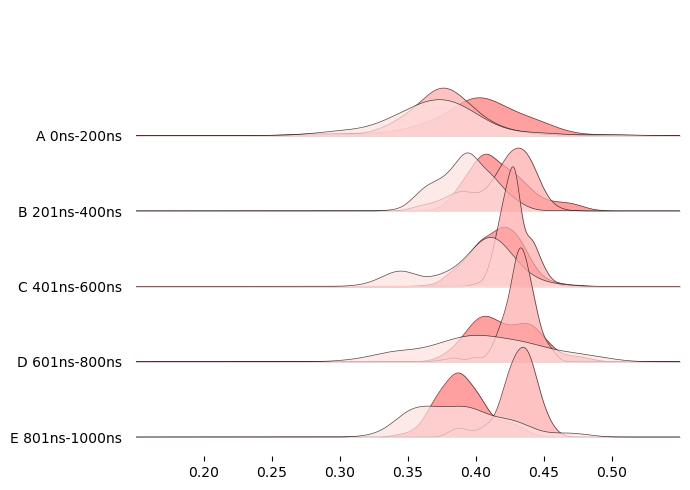

In [6]:
from joypy import joyplot

font = {'family':'helvetica neue',
    'color':  'black',
    'weight': 'bold',
    'size': 11
    }
rs={'family':'helvetica neue',
    'size':10
   }

fig, ax = plt.subplots(figsize=(7, 5))


p2=joyplot(
    data=pro_df,
    by="Time label",
    ylabelsize=10,
    legend=False,
    alpha=0.7,
    
    ax=ax,
    color=['#FF7878','#FFA8A8','#FEE1E1'],
    x_range=[0.15,0.55],
    normalize=False,
    linecolor=None,
    lw=0.5

    
)

plt.savefig('../../plots/RMSD_RMSF/time_block_rmsd_pro_rep.png', dpi=450,
           bbox_inches='tight',transparent=True)

In [7]:
unb_df=pd.DataFrame()
unb_df['S1']=rmsd_data['LC3BII_S1'].to_list()
unb_df['S2']=rmsd_data['LC3BII_S2'].to_list()
unb_df['S3']=rmsd_data['LC3BII_S3'].to_list()

unb_df['Time label']=tr_lab[:-1]
unb_df

,S1,S2,S3,Time label
0,8.000000e-07,0.000137,0.000517,A 0ns-200ns
1,2.139222e-01,0.189021,0.184487,A 0ns-200ns
2,2.210176e-01,0.188386,0.205279,A 0ns-200ns
3,2.244698e-01,0.182112,0.206535,A 0ns-200ns
4,2.170848e-01,0.170895,0.193378,A 0ns-200ns
...,...,...,...,...
995,3.473829e-01,0.252788,0.370716,E 801ns-1000ns
996,3.619345e-01,0.257242,0.394635,E 801ns-1000ns
997,3.722055e-01,0.269058,0.430265,E 801ns-1000ns
998,3.777209e-01,0.259986,0.416091,E 801ns-1000ns


/Users/jesucastin/anaconda3/lib/python3.11/site-packages/joypy/joyplot.py:435: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,


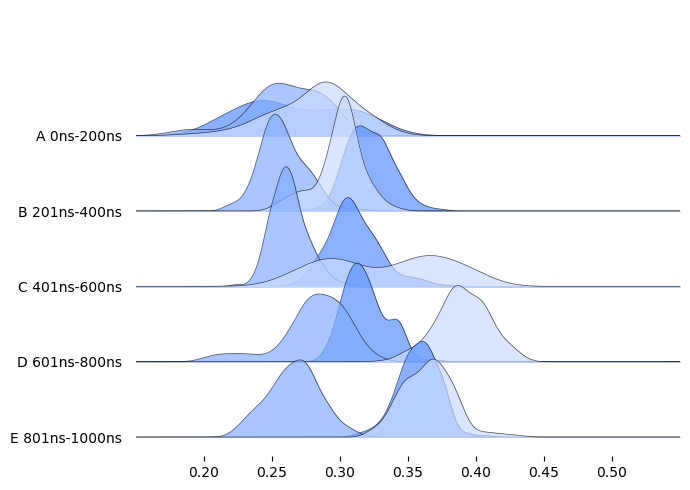

In [8]:
from joypy import joyplot

font = {'family':'helvetica neue',
    'color':  'black',
    'weight': 'bold',
    'size': 11
    }
rs={'family':'helvetica neue',
    'size':10
   }

fig, ax = plt.subplots(figsize=(7, 5))


p2=joyplot(
    data=unb_df,
    by="Time label",
    ylabelsize=10,
    legend=False,
    alpha=0.7,
    ax=ax,
    color=['#5A91FF','#85AEFF','#CBDCFF'],
    x_range=[0.15,0.55],
    normalize=False,
    linecolor=None,
    lw=0.5

    
)

plt.savefig('../../plots/RMSD_RMSF/time_block_rmsd_unb_rep.png', dpi=650,
           bbox_inches='tight',transparent=True)

In [9]:
bnd_df=pd.DataFrame()
bnd_df['S1']=rmsd_data['LC3BII_p62_S1'].to_list()
bnd_df['S2']=rmsd_data['LC3BII_p62_S2'].to_list()
bnd_df['S3']=rmsd_data['LC3BII_p62_S3'].to_list()

bnd_df['Time label']=tr_lab[:-1]
bnd_df

,S1,S2,S3,Time label
0,0.183775,0.183775,0.183776,A 0ns-200ns
1,0.157485,0.166495,0.152332,A 0ns-200ns
2,0.145390,0.160087,0.147309,A 0ns-200ns
3,0.198953,0.171657,0.192634,A 0ns-200ns
4,0.204886,0.191763,0.211684,A 0ns-200ns
...,...,...,...,...
995,0.214890,0.389084,0.245366,E 801ns-1000ns
996,0.207263,0.387967,0.249189,E 801ns-1000ns
997,0.198381,0.389731,0.255693,E 801ns-1000ns
998,0.217347,0.399353,0.264380,E 801ns-1000ns


/Users/jesucastin/anaconda3/lib/python3.11/site-packages/joypy/joyplot.py:435: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,


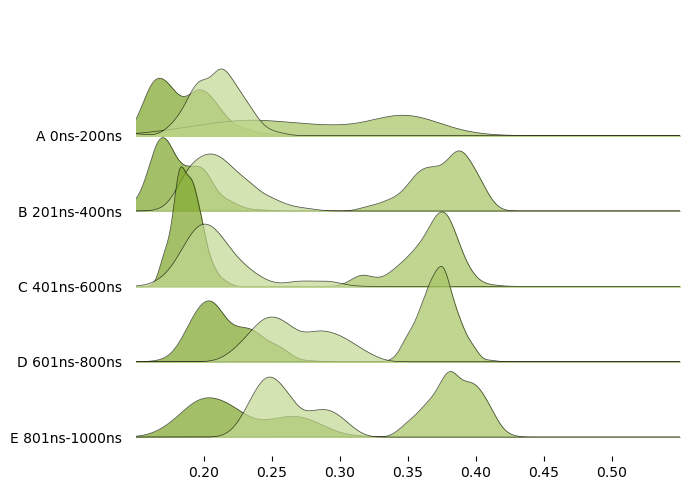

In [10]:
from joypy import joyplot

font = {'family':'helvetica neue',
    'color':  'black',
    'weight': 'bold',
    'size': 11
    }
rs={'family':'helvetica neue',
    'size':10
   }

fig, ax = plt.subplots(figsize=(7, 5))


p2=joyplot(
    data=bnd_df,
    by="Time label",
    ylabelsize=10,
    legend=False,
    alpha=0.7,
    ax=ax,
    color=['#7DA629','#A4C461','#C1D891'],
    x_range=[0.15,0.55],
    normalize=False,
    linecolor=None,
    lw=0.5

    
)

plt.savefig('../../plots/RMSD_RMSF/time_block_rmsd_bnd_rep.png', dpi=650,
           bbox_inches='tight',transparent=True)